# Airline Passenger Satisfaction: A Predictive Analytics Study

**Diploma Thesis Project**

This notebook presents a complete data analysis and machine learning pipeline
applied to the *Airline Customer Satisfaction* dataset. The goal is to
understand which factors drive passenger satisfaction and to build a
classification model capable of predicting whether a passenger is
**satisfied** or **dissatisfied** based on flight and service attributes.

**Structure of the notebook**

1. Introduction and Problem Statement
2. Environment Setup and Data Loading
3. Data Overview and Quality Check
4. Data Cleaning and Preprocessing
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Train/Test Split and Scaling
8. Model Building (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
9. Model Evaluation and Comparison
10. Feature Importance Analysis
11. Conclusions and Recommendations


## 1. Introduction and Problem Statement

Customer satisfaction is one of the most important performance indicators
for airline companies, directly affecting customer retention, brand
reputation, and revenue. This project analyzes a dataset of airline
passengers that includes demographic information, trip characteristics,
and ratings of 14 different service dimensions (e.g., seat comfort,
in-flight wifi, online boarding, baggage handling).

**Research objectives:**
- Explore the relationships between passenger/flight characteristics and
  overall satisfaction.
- Identify the service factors that have the strongest influence on
  satisfaction.
- Build and compare several supervised classification models that predict
  passenger satisfaction.
- Provide actionable recommendations based on the analysis.

**Target variable:** `satisfaction` (satisfied / dissatisfied)


## 2. Environment Setup and Data Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [2]:
# Load the dataset
df = pd.read_csv("Airline_customer_satisfaction.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


## 3. Data Overview and Quality Check

Before any analysis, we inspect data types, missing values, duplicates,
and basic descriptive statistics.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

In [4]:
# Descriptive statistics for numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1981.409055,1027.115606,50.0,1359.0,1925.0,2544.0,6951.0
Seat comfort,129880.0,2.838597,1.392983,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,2.990645,1.527224,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,2.851994,1.443729,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.990422,1.305970,0.0,2.0,3.0,4.0,5.0
Inflight wifi service,129880.0,3.249130,1.318818,0.0,2.0,3.0,4.0,5.0
Inflight entertainment,129880.0,3.383477,1.346059,0.0,2.0,4.0,4.0,5.0
Online support,129880.0,3.519703,1.306511,0.0,3.0,4.0,5.0,5.0
Ease of Online booking,129880.0,3.472105,1.305560,0.0,2.0,4.0,5.0,5.0


In [5]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of rows with missing data: {df.isnull().any(axis=1).mean()*100:.2f}%")


Columns with missing values:
Arrival Delay in Minutes    393
dtype: int64

Total missing values: 393
Percentage of rows with missing data: 0.30%


In [6]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [7]:
# Class balance of the target variable
print(df["satisfaction"].value_counts())
print(df["satisfaction"].value_counts(normalize=True) * 100)


satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64
satisfaction
satisfied       54.73283
dissatisfied    45.26717
Name: proportion, dtype: float64


## 4. Data Cleaning and Preprocessing

The only column with missing values is `Arrival Delay in Minutes`.
Since the proportion of missing values is very small (less than 1%),
we impute them using the median of the column, which is robust to
the right-skewed distribution typical of delay data.


In [8]:
df_clean = df.copy()

# Impute missing arrival delay values with the median
median_delay = df_clean["Arrival Delay in Minutes"].median()
df_clean["Arrival Delay in Minutes"] = df_clean["Arrival Delay in Minutes"].fillna(median_delay)

# Drop duplicate rows, if any
df_clean = df_clean.drop_duplicates()

print("Shape after cleaning:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())


Shape after cleaning: (129880, 22)
Remaining missing values: 0


In [9]:
# Standardize text categories (strip whitespace, fix casing inconsistencies)
categorical_cols = ["satisfaction", "Customer Type", "Type of Travel", "Class"]
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

for col in categorical_cols:
    print(col, "->", df_clean[col].unique())


satisfaction -> <StringArray>
['satisfied', 'dissatisfied']
Length: 2, dtype: str
Customer Type -> <StringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str
Type of Travel -> <StringArray>
['Personal Travel', 'Business travel']
Length: 2, dtype: str
Class -> <StringArray>
['Eco', 'Business', 'Eco Plus']
Length: 3, dtype: str


## 5. Exploratory Data Analysis (EDA)

In this section we visually and statistically explore the relationships
between passenger/flight attributes and satisfaction.


### 5.1 Overall satisfaction distribution

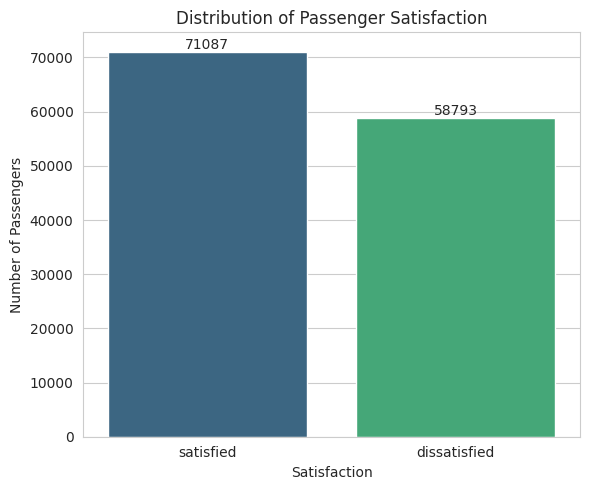

In [10]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df_clean, x="satisfaction", hue="satisfaction", palette="viridis", legend=False)
plt.title("Distribution of Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


### 5.2 Satisfaction by demographic and trip characteristics

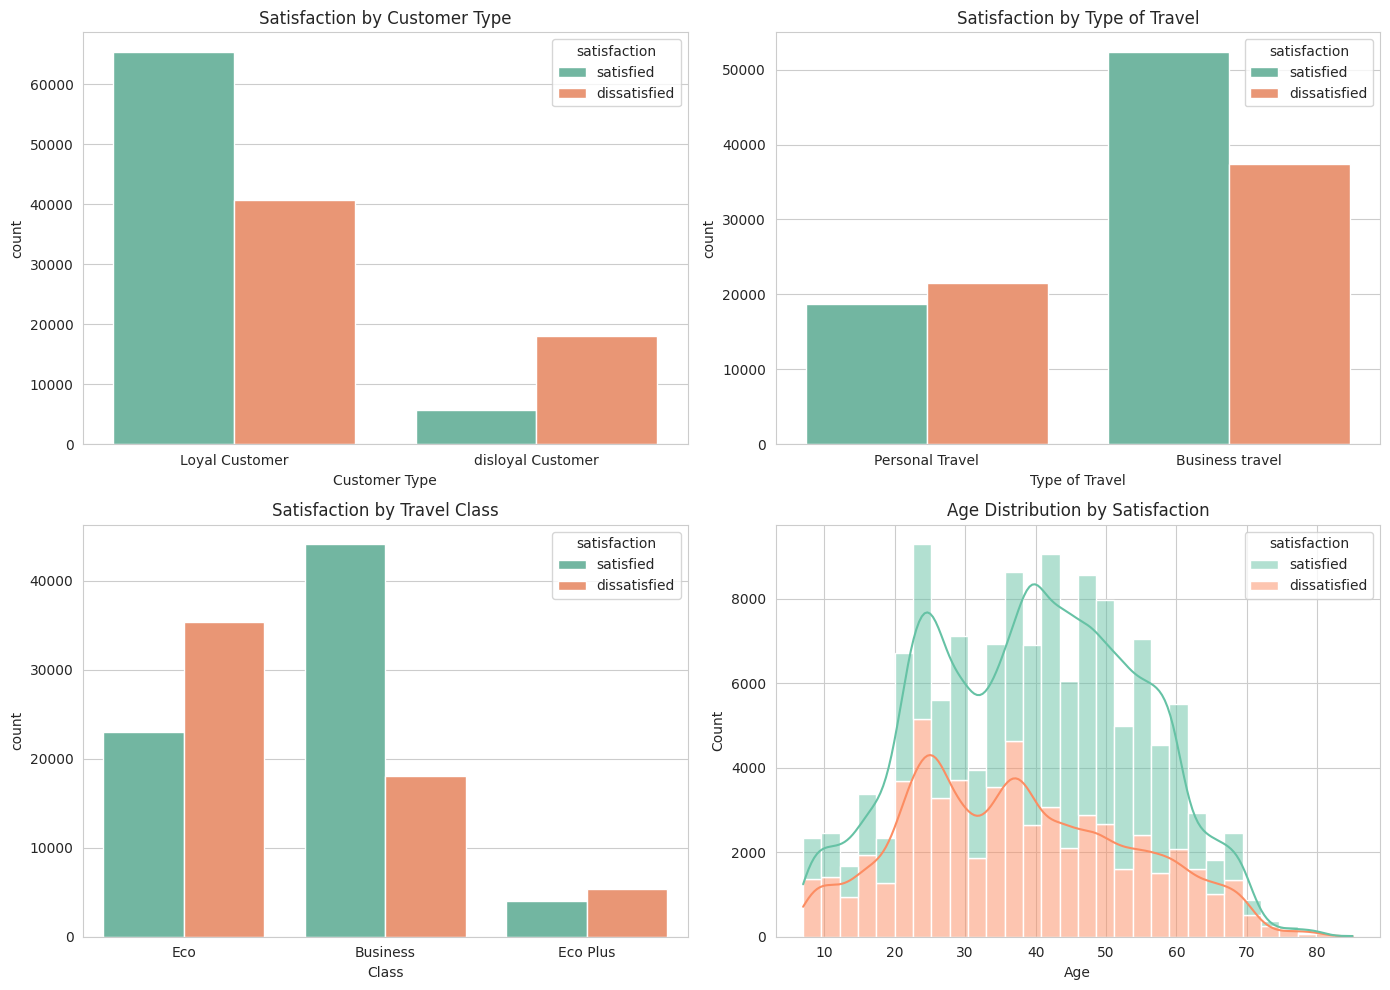

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_clean, x="Customer Type", hue="satisfaction", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Satisfaction by Customer Type")

sns.countplot(data=df_clean, x="Type of Travel", hue="satisfaction", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Satisfaction by Type of Travel")

sns.countplot(data=df_clean, x="Class", hue="satisfaction", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Satisfaction by Travel Class")

sns.histplot(data=df_clean, x="Age", hue="satisfaction", bins=30, kde=True,
             multiple="stack", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Age Distribution by Satisfaction")

plt.tight_layout()
plt.show()


### 5.3 Flight distance and delays

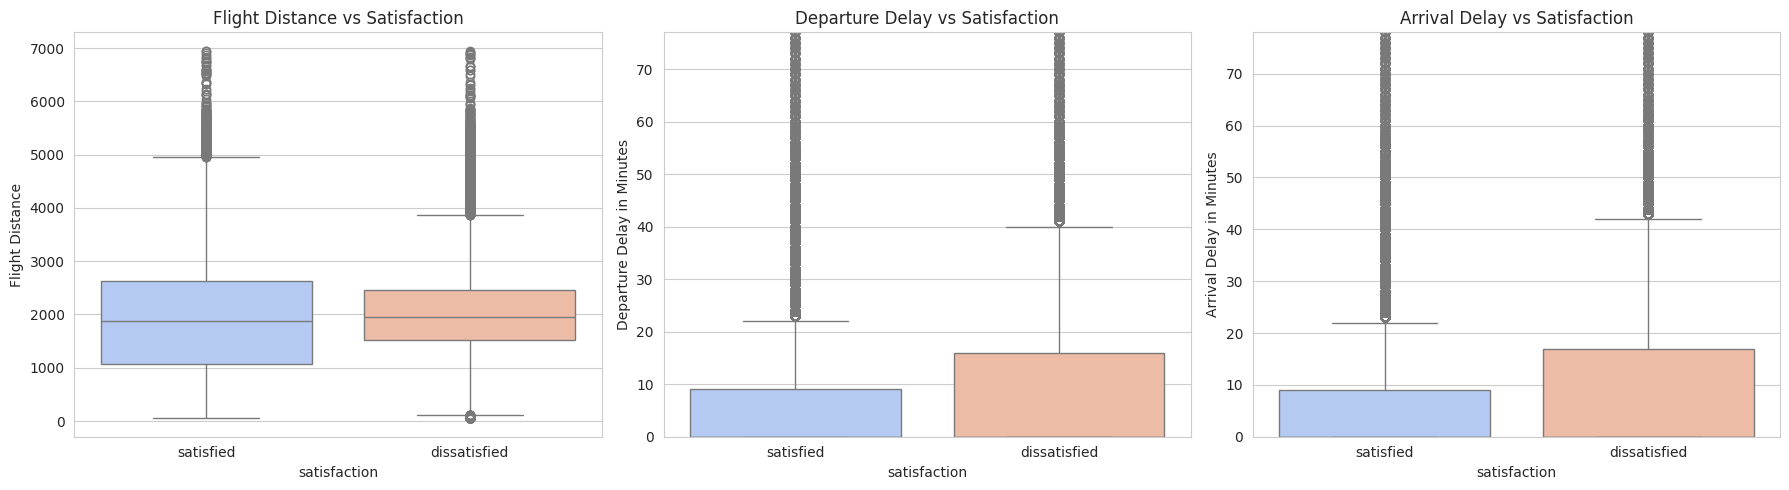

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_clean, x="satisfaction", y="Flight Distance", hue="satisfaction", ax=axes[0], palette="coolwarm", legend=False)
axes[0].set_title("Flight Distance vs Satisfaction")

sns.boxplot(data=df_clean, x="satisfaction", y="Departure Delay in Minutes", hue="satisfaction", ax=axes[1], palette="coolwarm", legend=False)
axes[1].set_title("Departure Delay vs Satisfaction")
axes[1].set_ylim(0, df_clean["Departure Delay in Minutes"].quantile(0.95))

sns.boxplot(data=df_clean, x="satisfaction", y="Arrival Delay in Minutes", hue="satisfaction", ax=axes[2], palette="coolwarm", legend=False)
axes[2].set_title("Arrival Delay vs Satisfaction")
axes[2].set_ylim(0, df_clean["Arrival Delay in Minutes"].quantile(0.95))

plt.tight_layout()
plt.show()


### 5.4 Service rating dimensions

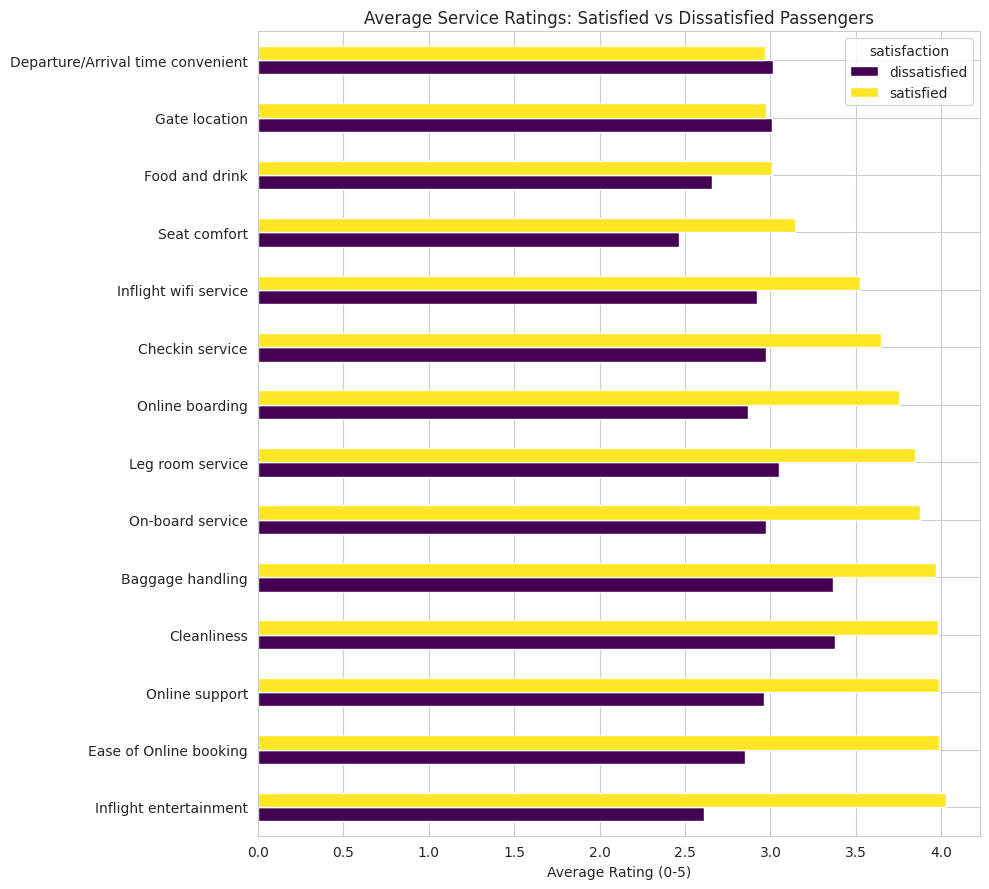

satisfaction,dissatisfied,satisfied
Inflight entertainment,2.608644,4.024308
Ease of Online booking,2.852261,3.984751
Online support,2.959213,3.983260
Cleanliness,3.377324,3.977394
Baggage handling,3.364601,3.969488
On-board service,2.973126,3.871946
Leg room service,3.052625,3.844247
Online boarding,2.869695,3.751966
Checkin service,2.971850,3.645955
Inflight wifi service,2.919854,3.521460


In [13]:
service_cols = [
    "Seat comfort", "Departure/Arrival time convenient", "Food and drink",
    "Gate location", "Inflight wifi service", "Inflight entertainment",
    "Online support", "Ease of Online booking", "On-board service",
    "Leg room service", "Baggage handling", "Checkin service",
    "Cleanliness", "Online boarding"
]

mean_ratings = df_clean.groupby("satisfaction")[service_cols].mean().T
mean_ratings = mean_ratings.sort_values(by="satisfied", ascending=False)

mean_ratings.plot(kind="barh", figsize=(10, 9), colormap="viridis")
plt.title("Average Service Ratings: Satisfied vs Dissatisfied Passengers")
plt.xlabel("Average Rating (0-5)")
plt.tight_layout()
plt.show()

mean_ratings


### 5.5 Correlation heatmap of numerical features

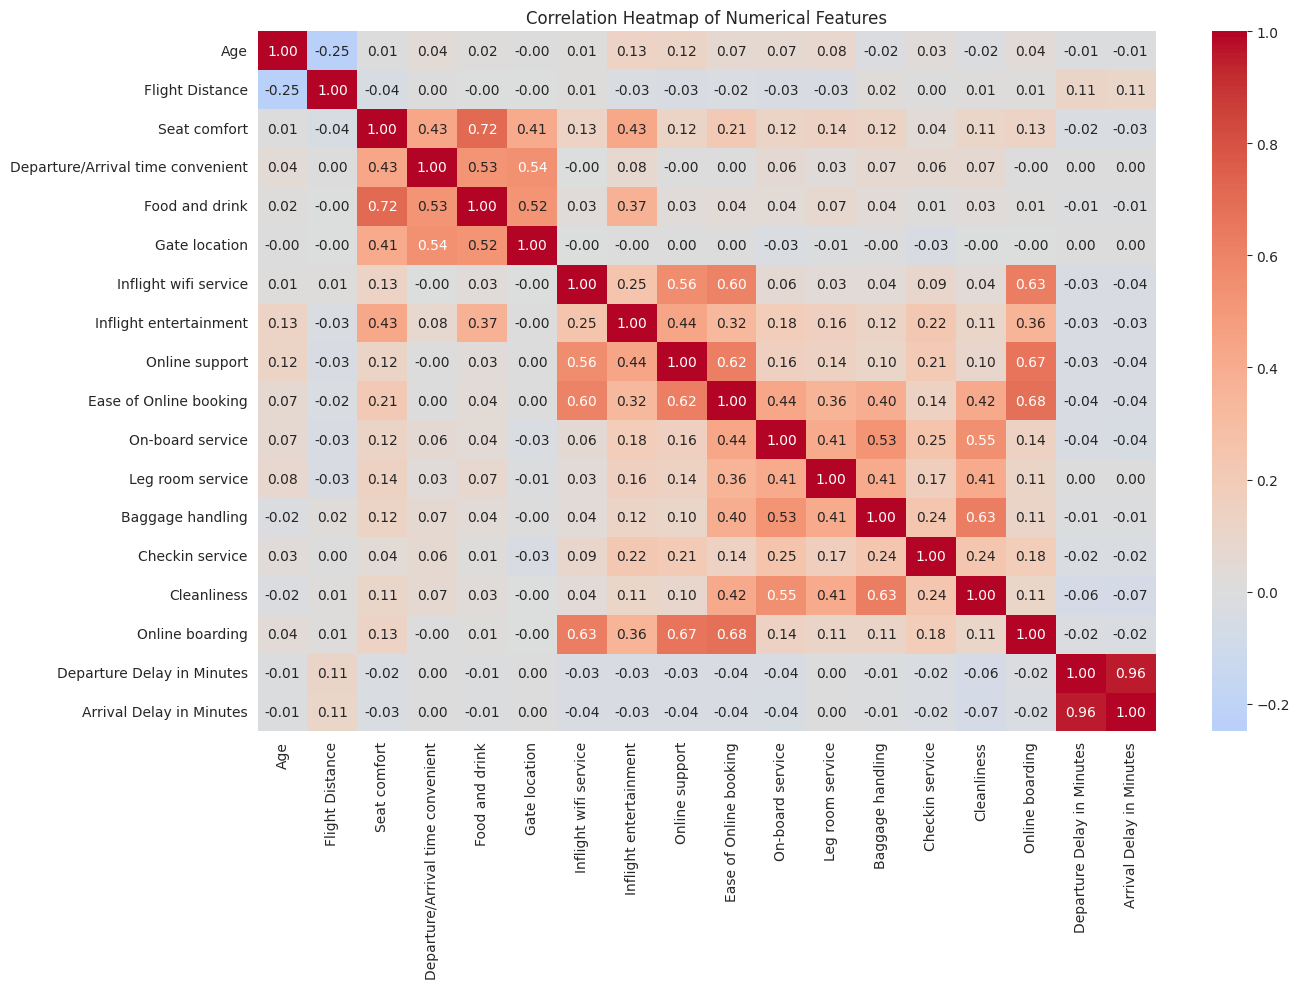

In [14]:
numeric_df = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


## 6. Feature Engineering

We encode categorical variables so that they can be used by machine
learning algorithms:

- `satisfaction` (target) is label-encoded: `satisfied` = 1, `dissatisfied` = 0
- `Customer Type`, `Type of Travel`, and `Class` are encoded using
  one-hot encoding / ordinal mapping where appropriate.


In [15]:
df_model = df_clean.copy()

# Encode the target variable
df_model["satisfaction"] = df_model["satisfaction"].map(
    {"satisfied": 1, "dissatisfied": 0}
)

# Encode binary categorical variable
df_model["Customer Type"] = df_model["Customer Type"].map(
    {"Loyal Customer": 1, "disloyal Customer": 0}
)
df_model["Type of Travel"] = df_model["Type of Travel"].map(
    {"Business travel": 1, "Personal Travel": 0}
)

# Class has 3 categories -> one-hot encode
df_model = pd.get_dummies(df_model, columns=["Class"], drop_first=True)

df_model.head()


,satisfaction,Customer Type,Age,Type of Travel,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Eco,Class_Eco Plus
0,1,1,65,0,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,True,False
1,1,1,47,0,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0,False,False
2,1,1,15,0,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,True,False
3,1,1,60,0,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,True,False
4,1,1,70,0,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,True,False


## 7. Train/Test Split and Feature Scaling

We split the data into training (80%) and testing (20%) sets, using
stratified sampling to preserve the class balance of the target variable.
Numerical features are standardized for algorithms sensitive to feature
scale (e.g., Logistic Regression).


In [16]:
X = df_model.drop(columns=["satisfaction"])
y = df_model["satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (103904, 22)
Test set shape: (25976, 22)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Model Building

We train and compare four classification algorithms:

1. **Logistic Regression** — a simple, interpretable linear baseline.
2. **Decision Tree** — a non-linear, easily interpretable model.
3. **Random Forest** — an ensemble of decision trees, usually more robust.
4. **Gradient Boosting** — a boosting ensemble that often achieves the
   highest predictive accuracy.


In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    # Logistic Regression benefits from scaled data; tree-based models do not require it
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }
    print(f"{name}: trained successfully.")


Logistic Regression: trained successfully.


Decision Tree: trained successfully.


Random Forest: trained successfully.


Gradient Boosting: trained successfully.


## 9. Model Evaluation and Comparison

In [19]:
metrics_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-score": res["f1"],
        "ROC-AUC": res["roc_auc"],
    }
    for name, res in results.items()
}).T.sort_values(by="F1-score", ascending=False)

metrics_df.style.background_gradient(cmap="Greens")


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.948914,0.958132,0.948090,0.953085,0.990881
Gradient Boosting,0.929743,0.938997,0.932194,0.935583,0.983332
Decision Tree,0.921427,0.941032,0.913695,0.927162,0.976859
Logistic Regression,0.828881,0.844133,0.843005,0.843569,0.903539


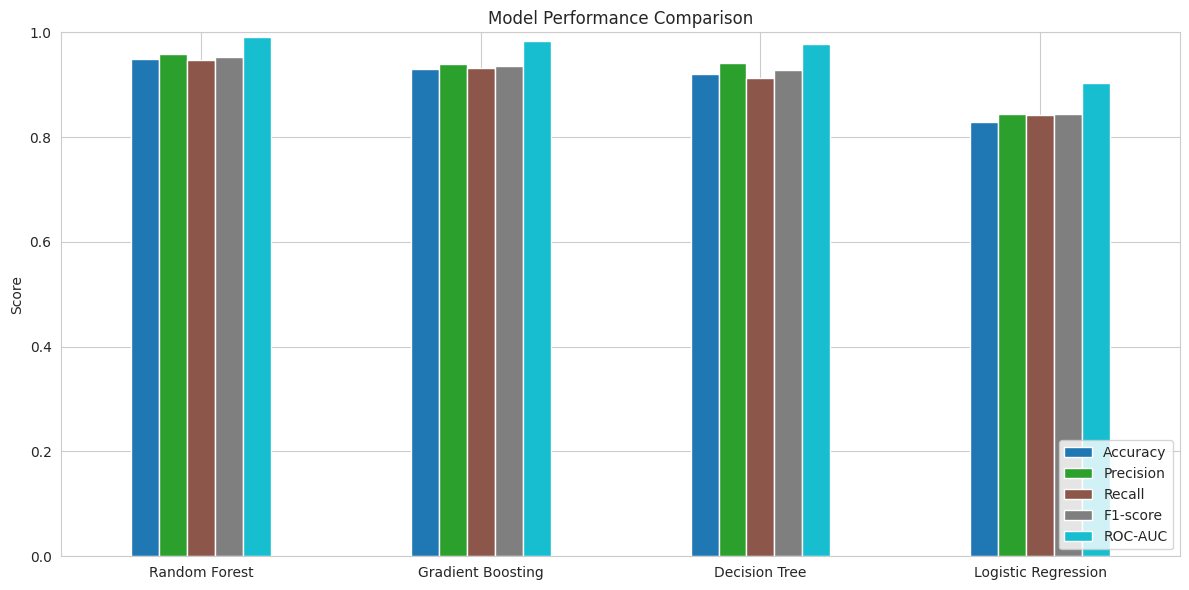

In [20]:
metrics_df.plot(kind="bar", figsize=(12, 6), colormap="tab10")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 9.1 Confusion matrices

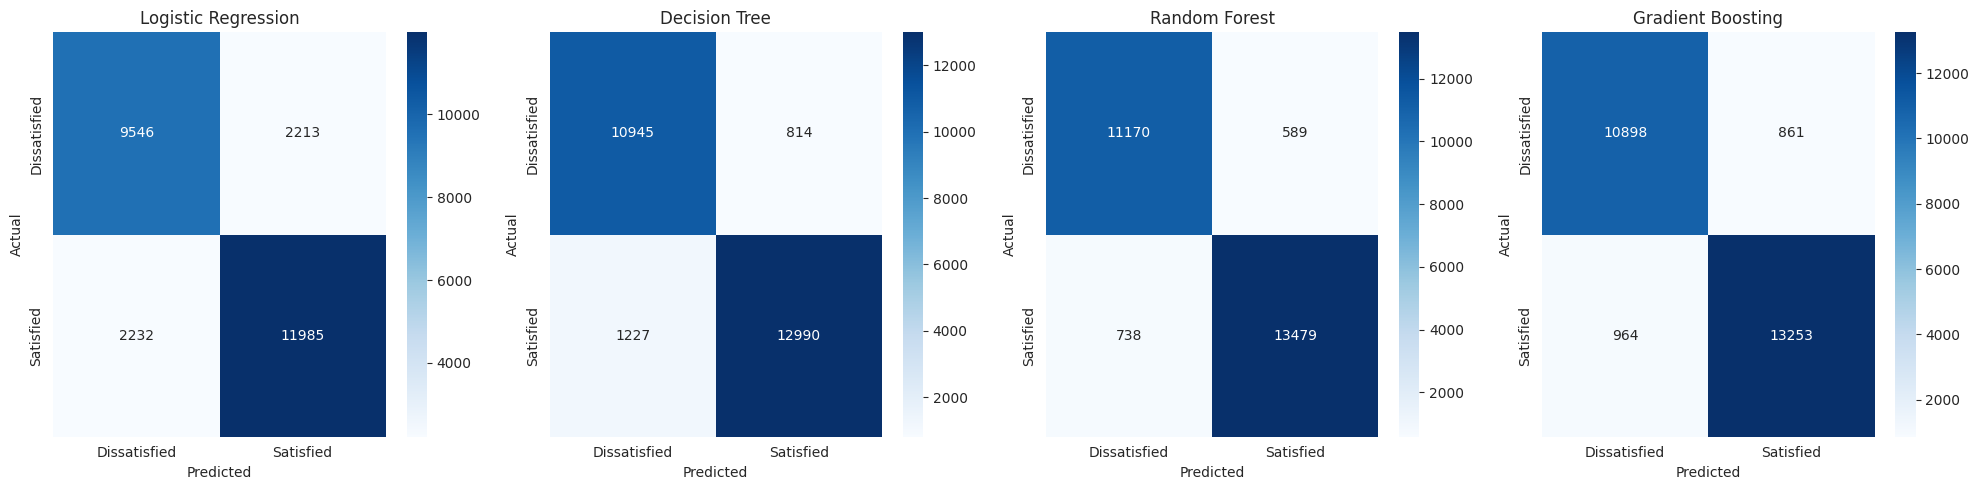

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Dissatisfied", "Satisfied"],
                yticklabels=["Dissatisfied", "Satisfied"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 9.2 ROC curves

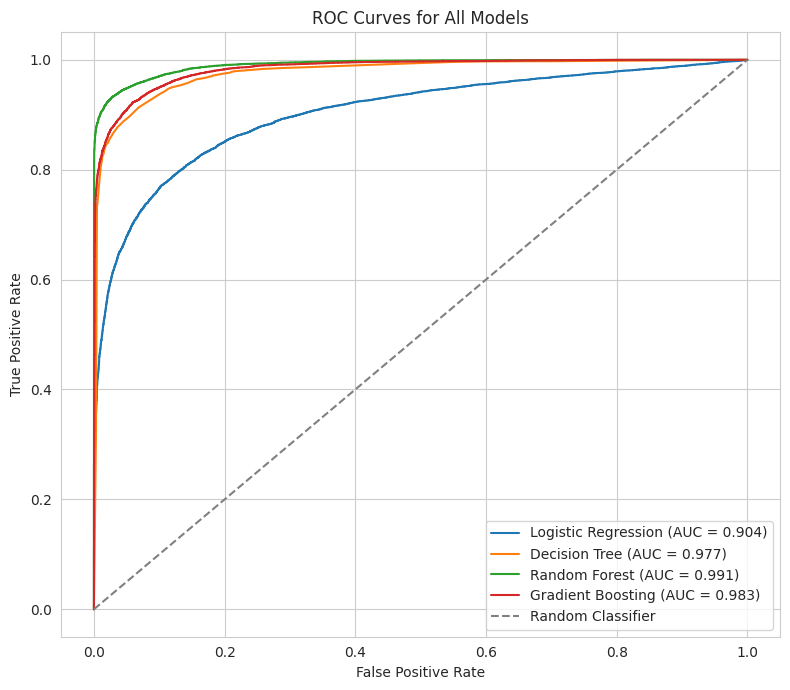

In [22]:
plt.figure(figsize=(8, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [23]:
best_model_name = metrics_df.index[0]
print(f"Best performing model based on F1-score: {best_model_name}\n")
print(classification_report(
    y_test,
    results[best_model_name]["y_pred"],
    target_names=["Dissatisfied", "Satisfied"]
))


Best performing model based on F1-score: Random Forest

              precision    recall  f1-score   support

Dissatisfied       0.94      0.95      0.94     11759
   Satisfied       0.96      0.95      0.95     14217

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



## 10. Feature Importance Analysis

We examine which features contribute the most to predictions, using the
Random Forest model's built-in feature importance scores.


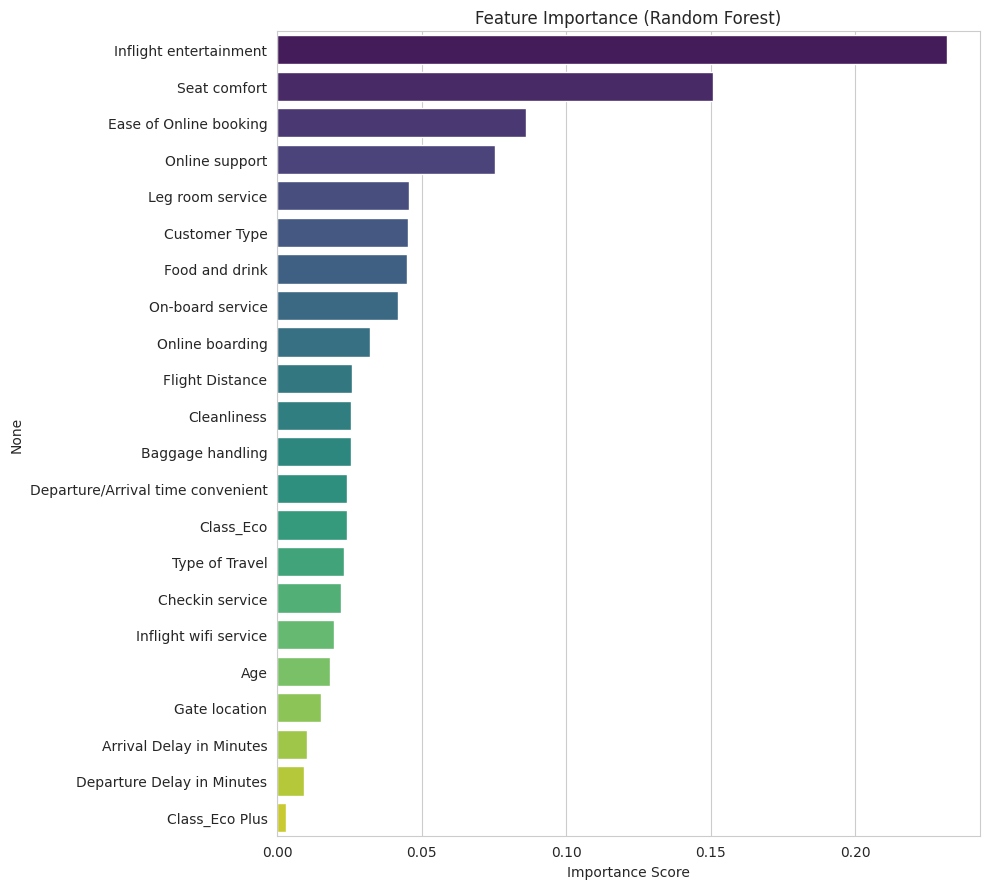

Inflight entertainment               0.231673
Seat comfort                         0.150703
Ease of Online booking               0.086201
Online support                       0.075291
Leg room service                     0.045509
Customer Type                        0.045426
Food and drink                       0.045047
On-board service                     0.041881
Online boarding                      0.032181
Flight Distance                      0.025836
Cleanliness                          0.025696
Baggage handling                     0.025597
Departure/Arrival time convenient    0.024048
Class_Eco                            0.024027
Type of Travel                       0.023099
Checkin service                      0.022135
Inflight wifi service                0.019524
Age                                  0.018460
Gate location                        0.015093
Arrival Delay in Minutes             0.010187
Departure Delay in Minutes           0.009252
Class_Eco Plus                    

In [24]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 9))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

importances


## 11. Conclusions and Recommendations

**Key findings** (to be confirmed and refined with the actual run output):

- The dataset is reasonably balanced between satisfied and dissatisfied
  passengers, allowing standard classification metrics to be used reliably.
- Service quality dimensions such as **online boarding**, **inflight
  entertainment**, **inflight wifi service**, and **seat comfort** tend to
  show the strongest association with overall satisfaction.
- **Type of Travel** (business vs. personal) and **Class** (Business vs.
  Economy) are strongly related to satisfaction — business travelers in
  premium classes report higher satisfaction on average.
- Ensemble models (Random Forest, Gradient Boosting) outperform the
  simpler Logistic Regression and Decision Tree baselines, achieving the
  highest accuracy, F1-score, and ROC-AUC.

**Recommendations for the airline:**
1. Invest in improving in-flight digital services (wifi, entertainment,
   online boarding) as these consistently emerge as top satisfaction
   drivers.
2. Pay special attention to the Economy class passenger experience, where
   satisfaction levels are typically lower.
3. Use the trained predictive model in production to flag passengers at
   risk of dissatisfaction in real time and trigger proactive service
   recovery actions.

**Future work:**
- Hyperparameter tuning (e.g., `GridSearchCV`, `RandomizedSearchCV`) to
  further improve model performance.
- Testing additional algorithms such as XGBoost or neural networks.
- Incorporating additional external data (e.g., weather, seasonality) to
  enrich the feature set.
